In [21]:
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [22]:
df = pd.read_csv("../data/document_data_clean.csv")

### 1) Verification of metadata fields

In [23]:
#Title
df_test = df.dropna(subset="title")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["title_clean", "title"]], headers='keys', tablefmt='psql'))

+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|       | title_clean                                                                                                                                            | title                                     

In [24]:
#Date
df_test = df.dropna(subset="date")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["date_clean", "date"]], headers='keys', tablefmt='psql'))

+-------+--------------+------------+
|       |   date_clean | date       |
|-------+--------------+------------|
| 31295 |         1905 | 1905-10-18 |
| 26519 |         1902 | 1902-11-23 |
|  4291 |         1888 | 1888-05-28 |
| 27869 |         1903 | 1903-07-26 |
| 16857 |         1899 | 1899-01-01 |
| 15706 |         1898 | 1898-03-30 |
| 21848 |         1900 | 1900-10-19 |
|  4990 |         1889 | 1889-05-15 |
| 11395 |         1895 | 1895       |
|  6362 |         1890 | 1890-11-05 |
| 31499 |         1905 | 1905-12-03 |
| 28569 |         1904 | 1904       |
| 36512 |         1909 | 1909       |
| 31974 |         1876 | 1876-12-18 |
| 55236 |         1880 | 1880-10-21 |
| 35865 |         1908 | 1908-07-01 |
|  6393 |         1890 | 1890-11-12 |
|  8840 |         1893 | 1893       |
| 14191 |         1897 | 1897-01-21 |
|   380 |         1884 | 1884-02-24 |
| 35848 |         1877 | 1877-06-09 |
| 14543 |         1897 | 1897-04-25 |
| 54978 |         1880 | 1880-09-01 |
| 57730 |   

In [25]:
#Author_name
df_test = df.dropna(subset="author")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["author_name_clean", "author"]], headers='keys', tablefmt='psql'))

+-------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|       | author_name_clean                                                                                                                                                                                                                                                                 | author                                                                                                                                 

In [26]:
#Author_birth
df_test = df.dropna(subset="author")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["author_birth_clean", "author"]], headers='keys', tablefmt='psql'))

+-------+----------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|       |   author_birth_clean | author                                                                                                                                                                                                                                                                                             |
|-------+----------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|  2549 |             

In [27]:
#Author_death
df_test = df.dropna(subset="author")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["author_death_clean", "author"]], headers='keys', tablefmt='psql'))

+-------+----------------------+-------------------------------------------------------------------------------------------------------------------------------------------------+
|       |   author_death_clean | author                                                                                                                                          |
|-------+----------------------+-------------------------------------------------------------------------------------------------------------------------------------------------|
| 24863 |                 1881 | Cortambert, Eugène (1805-1881). Auteur du texte                                                                                                 |
|    42 |                 1910 | Boussenard, Louis (1847-1910). Auteur du texte                                                                                                  |
| 30175 |                  nan | Indochine française. Auteur du texte                                    

In [28]:
#Publisher_name
df_test = df.dropna(subset="publisher")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["publisher_name_clean", "publisher"]], headers='keys', tablefmt='psql'))

+-------+--------------------------------------------------------------------+----------------------------------------------------------------------------+
|       | publisher_name_clean                                               | publisher                                                                  |
|-------+--------------------------------------------------------------------+----------------------------------------------------------------------------|
|  4738 | A. Cattier                                                         | A. Cattier (Tours)                                                         |
| 43141 | nan                                                                | [s.n.] (Paris)                                                             |
|  7191 | nan                                                                | [s.n.] (Paris)                                                             |
| 35517 | Le Progrès                                            

In [29]:
#Publisher_name
df_test = df.dropna(subset="publisher")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["publisher_place_clean", "publisher"]], headers='keys', tablefmt='psql'))

+-------+-------------------------+----------------------------------------------------+
|       | publisher_place_clean   | publisher                                          |
|-------+-------------------------+----------------------------------------------------|
| 21993 | Paris                   | [s. n.] (Paris)                                    |
| 42721 | Paris                   | H. Lauwereyns (Paris)                              |
| 45484 | Paris                   | au bureau du journal (Paris)                       |
| 10510 | Paris                   | [s.n.] (Paris)                                     |
|  5990 | Angers                  | [s. n.] (Angers)                                   |
| 56249 | Paris                   | [s.n.] (Paris)                                     |
| 19109 | Provins                 | [s.n.] (Provins)                                   |
| 35720 | Vierzon                 | [s.n.] (Vierzon)                                   |
| 38212 | Tananarive 

In [30]:
#Type
df_test = df.dropna(subset="type")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabulate(df_test.sample(100)[["type_clean", "type", "title"]], headers='keys', tablefmt='psql'))

+-------+--------------------+----------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|       | type_clean         | type                 | title                                                                                                                                                                                                                                                                                           |
|-------+--------------------+----------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 2) Elaboration filtre

In [31]:
df = pd.read_csv("../data/document_data_clean.csv")
df = df[['ark', 'title_clean', 'date_clean', "author_name_clean", "author_type_clean", "publisher_name_clean", "publisher_place_clean", "type_clean"]]
df_all_metadata = df.dropna()
df_author = df.dropna(subset = "author_type_clean")
df_publisher = df.dropna(subset = "publisher_name_clean")
df_author_pub = pd.concat([df_author,df_publisher]).drop_duplicates().reset_index(drop=True)
df_date = df.dropna(subset = "date_clean")
df_random = df.sample(20000)
df_random_metadata = df_random.dropna()
df_title = df.dropna(subset = "title_clean")
print(f"Length df_all_metadata: {len(df_all_metadata)}")
print(f"Length df_author: {len(df_author)}")
print(f"Length df_publisher: {len(df_publisher)}")
print(f"Length df_author_pub: {len(df_author_pub)}")
print(f"Length df_random: {len(df_random)}")
print(f"Length df_random_metadata: {len(df_random_metadata)}")
print(f"Length df_date: {len(df_date)}")
print(f"Length df_title: {len(df_title)}")

Length df_all_metadata: 6592
Length df_author: 11276
Length df_publisher: 14392
Length df_author_pub: 19033
Length df_random: 20000
Length df_random_metadata: 2231
Length df_date: 58125
Length df_title: 58156


Text(0.5, 1.0, 'Distribution of the publishing dates')

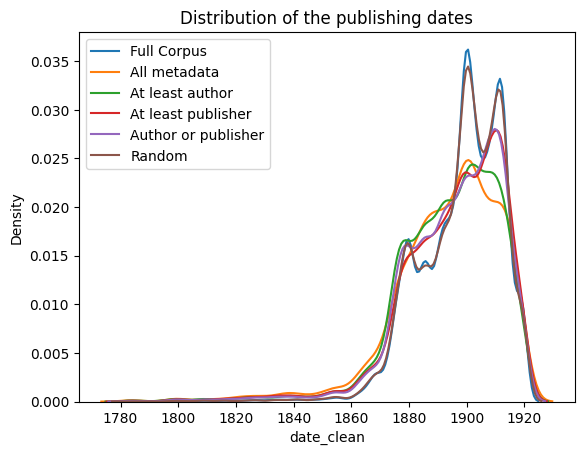

In [32]:
# Date distribution:
sns.kdeplot(df["date_clean"])
sns.kdeplot(df_all_metadata["date_clean"])
sns.kdeplot(df_author["date_clean"])
sns.kdeplot(df_publisher["date_clean"])
sns.kdeplot(df_author_pub["date_clean"])
sns.kdeplot(df_random["date_clean"])
plt.legend(["Full Corpus", "All metadata", "At least author", "At least publisher", "Author or publisher", "Random"])
plt.title("Distribution of the publishing dates")

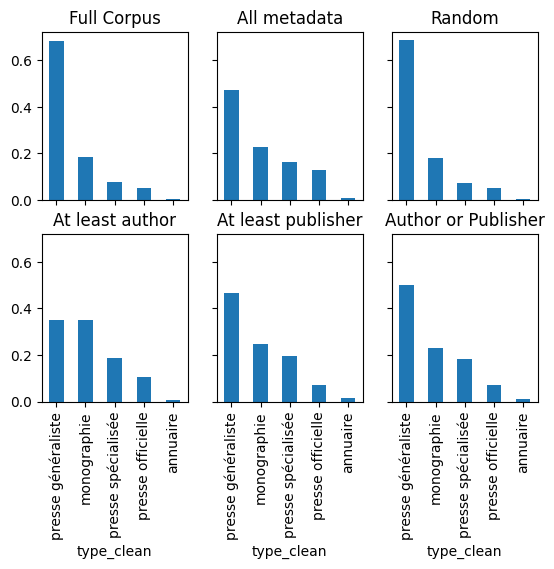

In [33]:
# Type distribution:
fig, ax = plt.subplots(2, 3, sharey=True, sharex=True)
plt.sca(ax[0][0])
plt.title("Full Corpus")
df["type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[0][1])
plt.title("All metadata")
df_all_metadata["type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[0][2])
plt.title("Random")
df_random["type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[1][0])
plt.title("At least author")
df_author["type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[1][1])
plt.title("At least publisher")
df_publisher["type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[1][2])
plt.title("Author or Publisher")
df_author_pub["type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.show()

type_clean
presse généraliste    39675
presse spécialisée    10670
monographie            4496
presse officielle      3053
annuaire                262
Name: count, dtype: int64
type_clean
monographie           3102
presse spécialisée    1493
presse généraliste    1089
presse officielle      856
annuaire                52
Name: count, dtype: int64
type_clean
presse généraliste    13726
presse spécialisée     3598
monographie            1500
presse officielle      1081
annuaire                 95
Name: count, dtype: int64
type_clean
monographie           3975
presse généraliste    3940
presse spécialisée    2105
presse officielle     1176
annuaire                80
Name: count, dtype: int64
type_clean
presse généraliste    6689
monographie           3591
presse spécialisée    2850
presse officielle     1051
annuaire               211
Name: count, dtype: int64
type_clean
presse généraliste    9538
monographie           4424
presse spécialisée    3461
presse officielle     1371
annuaire   

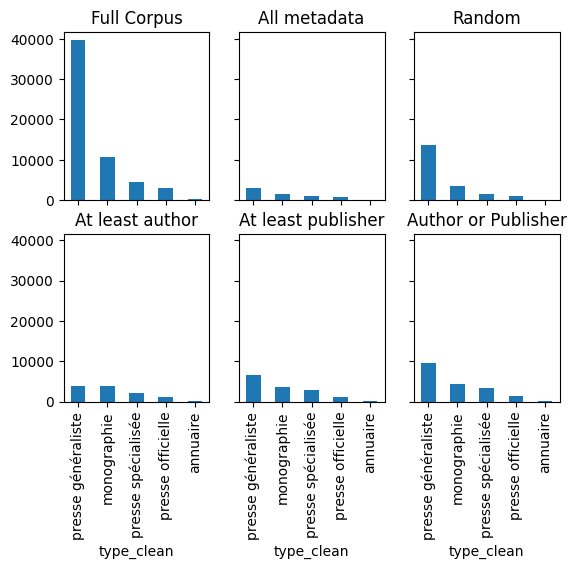

In [34]:
# Type absolute:
fig, ax = plt.subplots(2, 3, sharey=True, sharex=True)
plt.sca(ax[0][0])
plt.title("Full Corpus")
df["type_clean"].value_counts().plot(kind="bar")
print(df["type_clean"].value_counts())
plt.sca(ax[0][1])
plt.title("All metadata")
df_all_metadata["type_clean"].value_counts().plot(kind="bar")
print(df_all_metadata["type_clean"].value_counts())
plt.sca(ax[0][2])
plt.title("Random")
df_random["type_clean"].value_counts().plot(kind="bar")
print(df_random["type_clean"].value_counts())
plt.sca(ax[1][0])
plt.title("At least author")
df_author["type_clean"].value_counts().plot(kind="bar")
print(df_author["type_clean"].value_counts())
plt.sca(ax[1][1])
plt.title("At least publisher")
df_publisher["type_clean"].value_counts().plot(kind="bar")
print(df_publisher["type_clean"].value_counts())
plt.sca(ax[1][2])
plt.title("Author or Publisher")
df_author_pub["type_clean"].value_counts().plot(kind="bar")
print(df_author_pub["type_clean"].value_counts())
plt.show()

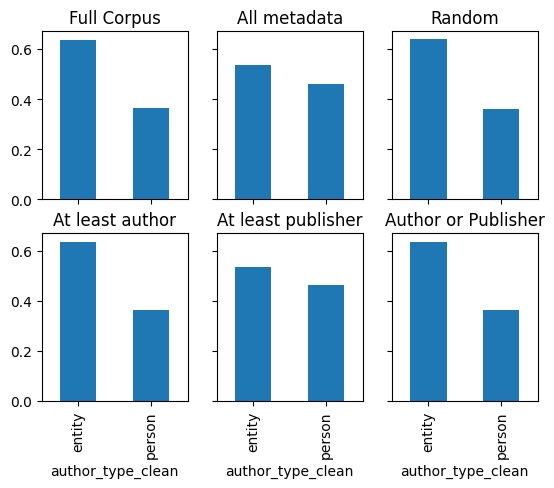

In [35]:
# Author type distribution:
fig, ax = plt.subplots(2, 3, sharey=True, sharex=True)
plt.sca(ax[0][0])
plt.title("Full Corpus")
df["author_type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[0][1])
plt.title("All metadata")
df_all_metadata["author_type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[0][2])
plt.title("Random")
df_random["author_type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[1][0])
plt.title("At least author")
df_author["author_type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[1][1])
plt.title("At least publisher")
df_publisher["author_type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.sca(ax[1][2])
plt.title("Author or Publisher")
df_author_pub["author_type_clean"].value_counts(normalize=True).plot(kind="bar")
plt.show()

In [36]:
#Top 20 filtered / non-filtered
print(df["publisher_place_clean"].value_counts(normalize=True).sort_values(ascending=False)[:10])
print(df_all_metadata["publisher_place_clean"].value_counts(normalize=True).sort_values(ascending=False)[:10])
print(df_author["publisher_place_clean"].value_counts(normalize=True).sort_values(ascending=False)[:10])
print(df_publisher["publisher_place_clean"].value_counts(normalize=True).sort_values(ascending=False)[:10])
print(df_random["publisher_place_clean"].value_counts(normalize=True).sort_values(ascending=False)[:10])
print(df_author_pub["publisher_place_clean"].value_counts(normalize=True).sort_values(ascending=False)[:10])

publisher_place_clean
Paris         0.484776
Alger         0.122414
Lyon          0.026293
Marseille     0.022966
Toulouse      0.016879
Oran          0.015328
Bordeaux      0.011534
Dijon         0.011414
Pau           0.011414
Tananarive    0.009466
Name: proportion, dtype: float64
publisher_place_clean
Paris          0.641080
Tananarive     0.074029
Alger          0.045661
Lyon           0.026244
Lille          0.011377
Montpellier    0.009405
Tunis          0.008192
Tours          0.007737
Bruxelles      0.007282
Bordeaux       0.006523
Name: proportion, dtype: float64
publisher_place_clean
Paris          0.532388
Alger          0.099946
Tananarive     0.045667
Lyon           0.020635
Hyères         0.013458
Montpellier    0.010138
Brest          0.010138
Mende          0.009510
Toulouse       0.009241
Angers         0.008792
Name: proportion, dtype: float64
publisher_place_clean
Paris         0.639783
Lyon          0.097785
Alger         0.039490
Tananarive    0.033988
Bourges    